In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving product_category_name_translation.csv to product_category_name_translation.csv


In [ ]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')

print("Done")

Done


In [ ]:
# Check shapes
print(orders.shape)
print(reviews.shape)
print(customers.shape)

# Check if any order has multiple reviews (common issue)
print(reviews['order_id'].value_counts().head())

(99441, 8)
(99224, 7)
(99441, 5)
order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
843be4a0dcdb9716de7652d53af4acab    2
Name: count, dtype: int64


In [ ]:
# Keep only the latest review per order
reviews = reviews.sort_values('review_creation_date', ascending=False)
reviews = reviews.drop_duplicates(subset='order_id', keep='first')

# Now join
df = orders.merge(reviews[['order_id','review_score']], on='order_id', how='left')
df = df.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')

# Verify no duplicates
print(df.shape)
print(df.duplicated('order_id').sum())  # should be 0

(99441, 10)
0


In [ ]:
# Parse dates
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Calculate delay (positive = early, negative = late)
df['days_difference'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# Keep only delivered orders
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Classify
def classify(d):
    if d >= 0: return 'On Time'
    elif d >= -5: return 'Late'
    else: return 'Super Late'

df_delivered['delivery_status'] = df_delivered['days_difference'].apply(classify)

# Quick check
print(df_delivered['delivery_status'].value_counts())
print(df_delivered.shape)

delivery_status
On Time       88644
Super Late     4219
Late           3615
Name: count, dtype: int64
(96478, 12)


In [ ]:
state_stats = df_delivered.groupby('customer_state').agg(
    total=('order_id', 'count'),
    late=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

state_stats['late_pct'] = (state_stats['late'] / state_stats['total'] * 100).round(1)
state_stats = state_stats.sort_values('late_pct', ascending=False)

print(state_stats.head(10))

   customer_state  total  late  late_pct
1              AL    397    95      23.9
9              MA    717   141      19.7
16             PI    476    76      16.0
5              CE   1279   196      15.3
24             SE    335    51      15.2
4              BA   3256   457      14.0
18             RJ  12350  1664      13.5
26             TO    274    35      12.8
13             PA    946   117      12.4
21             RR     41     5      12.2


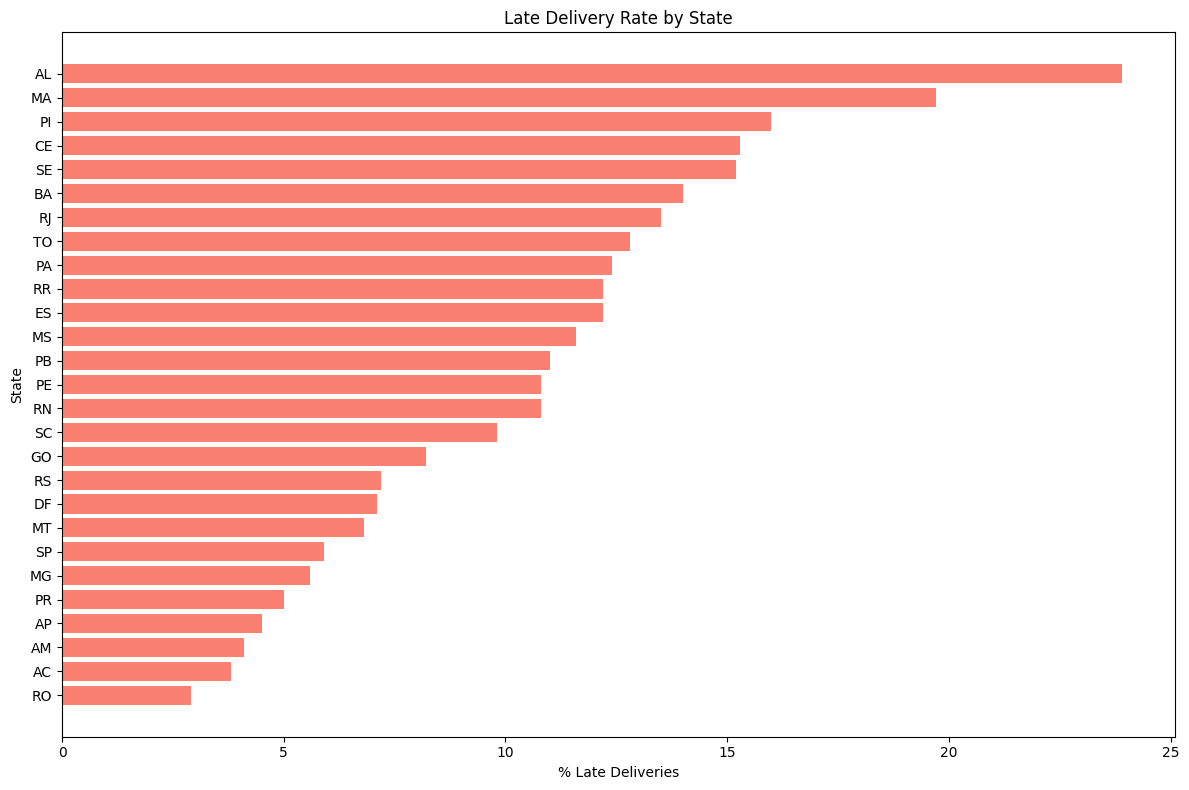

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.barh(state_stats['customer_state'], state_stats['late_pct'], color='salmon')
plt.xlabel('% Late Deliveries')
plt.ylabel('State')
plt.title('Late Delivery Rate by State')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

delivery_status
Late          3.46
On Time       4.29
Super Late    1.79
Name: review_score, dtype: float64


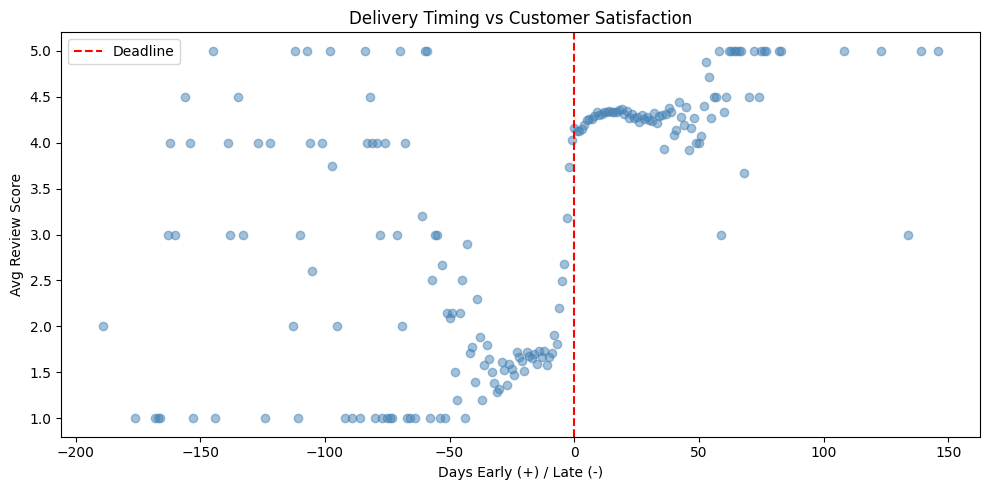

In [ ]:
# Average review score by delivery status
print(df_delivered.groupby('delivery_status')['review_score'].mean().round(2))

# Scatter plot: delay days vs review score
delay_vs_score = df_delivered.groupby('days_difference')['review_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.scatter(delay_vs_score['days_difference'], delay_vs_score['review_score'], alpha=0.5, color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Deadline')
plt.xlabel('Days Early (+) / Late (-)')
plt.ylabel('Avg Review Score')
plt.title('Delivery Timing vs Customer Satisfaction')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df_delivered.groupby('delivery_status')['review_score'].mean().round(2))

delivery_status
Late          3.46
On Time       4.29
Super Late    1.79
Name: review_score, dtype: float64


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv


In [ ]:
# Merge translations into products
products = products.merge(translations, on='product_category_name', how='left')

# Load order items
order_items = pd.read_csv('olist_order_items_dataset.csv')

# Join to delivered orders
df_full = df_delivered.merge(order_items[['order_id','product_id']], on='order_id', how='left')
df_full = df_full.merge(products[['product_id','product_category_name_english']], on='product_id', how='left')

print(df_full['product_category_name_english'].value_counts().head(10))

product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
Name: count, dtype: int64


  purchase_day  total  late  late_pct
1       Monday  15701  1421       9.1
5      Tuesday  15503  1317       8.5
6    Wednesday  15076  1178       7.8
4     Thursday  14323  1085       7.6
0       Friday  13685  1157       8.5
2     Saturday  10555   802       7.6
3       Sunday  11635   874       7.5


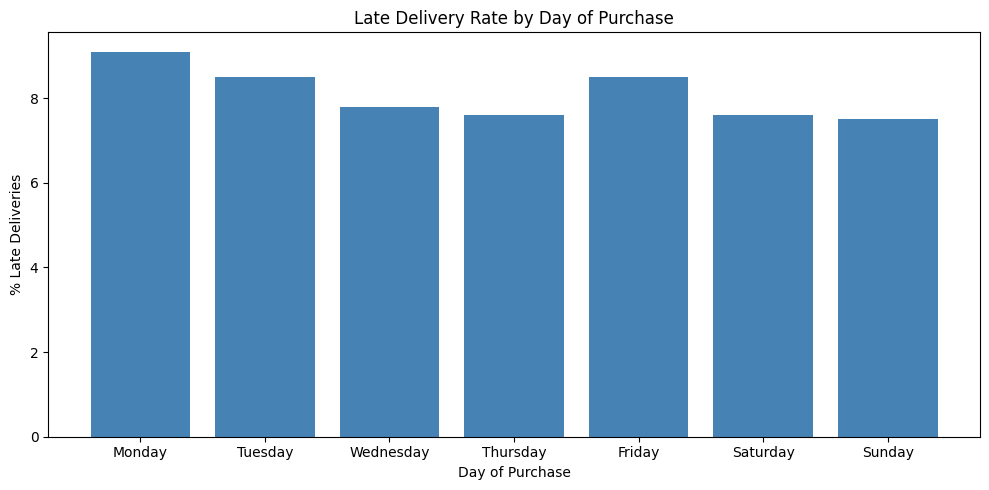

In [ ]:
# Extract day of week order was purchased
df_delivered['order_purchase_timestamp'] = pd.to_datetime(df_delivered['order_purchase_timestamp'])
df_delivered['purchase_day'] = df_delivered['order_purchase_timestamp'].dt.day_name()

# Late rate by day
day_stats = df_delivered.groupby('purchase_day').agg(
    total=('order_id', 'count'),
    late=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

day_stats['late_pct'] = (day_stats['late'] / day_stats['total'] * 100).round(1)

# Sort by week order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_stats['purchase_day'] = pd.Categorical(day_stats['purchase_day'], categories=day_order, ordered=True)
day_stats = day_stats.sort_values('purchase_day')

print(day_stats)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(day_stats['purchase_day'], day_stats['late_pct'], color='steelblue')
plt.xlabel('Day of Purchase')
plt.ylabel('% Late Deliveries')
plt.title('Late Delivery Rate by Day of Purchase')
plt.tight_layout()
plt.show()

In [ ]:
# Save cleaned dataframes
df_delivered.to_csv('df_delivered.csv', index=False)
state_stats.to_csv('state_stats.csv', index=False)
day_stats.to_csv('day_stats.csv', index=False)

# Download them
from google.colab import files
files.download('df_delivered.csv')
files.download('state_stats.csv')
files.download('day_stats.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>